In [1]:
# ==============================================================================
# AUTO-INSTALLER DEPENDENCIES
# ==============================================================================
import subprocess
import sys

# Memeriksa dan menginstal library yang belum ada
def install_packages():
    packages = ["keras-tuner", "yfinance"]
    for package in packages:
        try:
            __import__(package.replace("-", "_"))
        except ImportError:
            print(f"Menginstal {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_packages()


Menginstal keras-tuner...


TAHAP 1: INPUT DATA & EKSPLORASI


/tmp/ipykernel_709/1812828425.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)



--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---
                     Min  Kuartil Pertama      Median         Mean  Kuartil Ketiga          Max  Standar Deviasi
Price Ticker                                                                                                    
High  BBRI.JK  39.541189       303.094325  945.169974  1361.557014     2169.414869  4811.545089      1225.064166

Menampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)


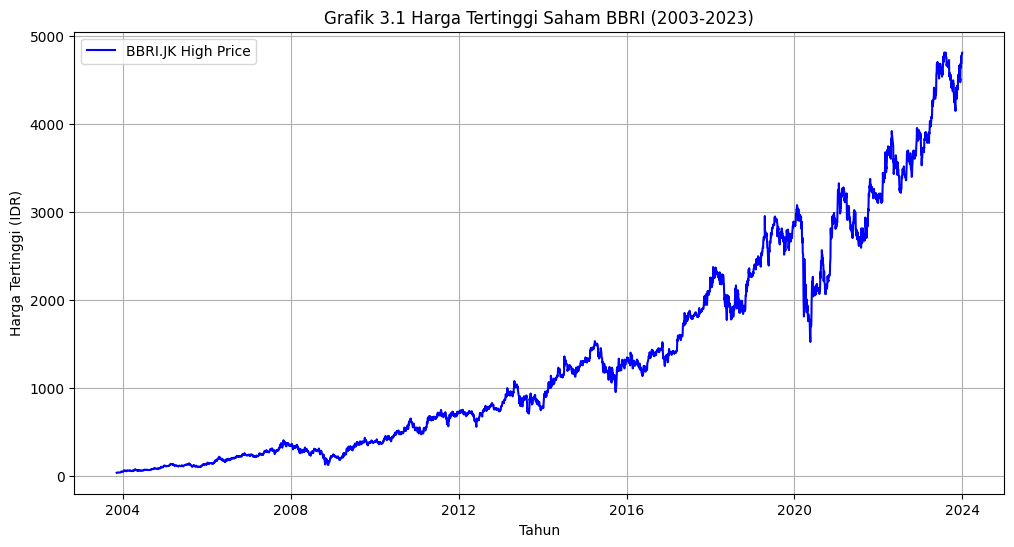

In [2]:
# ==============================================================================
# KODE UTAMA BI-LSTM
# ==============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
# Pastikan kedua callback ini ada di sini:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Mengunci Random Seed agar hasil konsisten
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("TAHAP 1: INPUT DATA & EKSPLORASI")
print("="*60)

# Mengunduh data sesuai rentang jurnal
df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)
data_high = df[['High']].dropna()
data = data_high.values.reshape(-1, 1)

# 1. Tabel Statistika Deskriptif Data dalam Satuan IDR
print("\n--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---")
desc_stats = data_high.describe().T
desc_stats['Kuartil Pertama'] = data_high.quantile(0.25).values
desc_stats['Median'] = data_high.median().values
desc_stats['Kuartil Ketiga'] = data_high.quantile(0.75).values
desc_stats = desc_stats[['min', 'Kuartil Pertama', 'Median', 'mean', 'Kuartil Ketiga', 'max', 'std']]
desc_stats.columns = ['Min', 'Kuartil Pertama', 'Median', 'Mean', 'Kuartil Ketiga', 'Max', 'Standar Deviasi']
print(desc_stats.to_string())

# 2. Grafik Harga Tertinggi Saham
print("\nMenampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)")
plt.figure(figsize=(12, 6))
plt.plot(data_high.index, data_high['High'], color='blue', label='BBRI.JK High Price')
plt.title('Grafik 3.1 Harga Tertinggi Saham BBRI (2003-2023)')
plt.xlabel('Tahun')
plt.ylabel('Harga Tertinggi (IDR)')
plt.grid(True)
plt.legend()
plt.show()


In [3]:
print("\n" + "="*60)
print("TAHAP 2: PREPROCESSING & PEMBAGIAN DATA")
print("="*60)

# Normalisasi menggunakan Min-Max Scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Tabel Normalisasi Data (Perbaikan Format Desimal)
print("\n--- Tabel 3.2 Normalisasi Data (Cuplikan) ---")
df_norm = pd.DataFrame(scaled_data, index=data_high.index, columns=['Harga Tertinggi Harian (Norm)'])
# Mengatur format Pandas agar mencetak 8 angka di belakang koma (tanpa notasi ilmiah 'e')
pd.set_option('display.float_format', lambda x: '%.8f' % x)
print(pd.concat([df_norm.head(), df_norm.tail()]))
# Mengembalikan format pandas ke default
pd.reset_option('display.float_format')

# Segmentasi (Window Size 60)
window_size = 60
def create_sequences(dataset, window):
    X_seq, y_seq = [], []
    for i in range(window, len(dataset)):
        X_seq.append(dataset[i-window:i, 0])
        y_seq.append(dataset[i, 0])
    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(scaled_data, window_size)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Pembagian data 50:50 sesuai jurnal
train_size = int(len(X) * 0.5)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 4. Tabel Hasil Pengujian Perbandingan
print("\n--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---")
df_split = pd.DataFrame({
    'Perbandingan': ['50:50'],
    'Data Latih (Training)': [len(X_train)],
    'Data Uji (Testing)': [len(X_test)]
})
print(df_split.to_string(index=False))



TAHAP 2: PREPROCESSING & PEMBAGIAN DATA

--- Tabel 3.2 Normalisasi Data (Cuplikan) ---
            Harga Tertinggi Harian (Norm)
Date                                     
2003-11-11                     0.00000000
2003-11-12                     0.00041431
2003-11-13                     0.00041431
2003-11-14                     0.00041431
2003-11-17                     0.00020715
2023-12-21                     0.97369682
2023-12-22                     0.99123236
2023-12-27                     0.99561604
2023-12-28                     0.99999983
2023-12-29                     0.99999983

--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---
Perbandingan  Data Latih (Training)  Data Uji (Testing)
       50:50                   2469                2470


In [4]:
print("\n" + "="*60)
print("TAHAP 3A: PENCARIAN PARAMETER (BAYESIAN OPTIMIZATION REVISI)")
print("="*60)

# 5. Tabel Inisialisasi Parameter Bi-LSTM (Update Epoch & Early Stopping)
print("\n--- Tabel 3.4 Inisialisasi Parameter Bi-LSTM (Ruang Pencarian) ---")
df_init_params = pd.DataFrame({
    'Parameter': ['Neuron', 'Optimasi', 'Learning Rate', 'Batch Size', 'Max Epoch', 'Early Stopping'],
    'Opsi / Rentang': ['50', 'Adam, RMSprop, SGD', '0.01, 0.001', '1, 16, 32, 64', '50', 'Patience: 5']
})
print(df_init_params.to_string(index=False))

# 1. Update fungsi build_model
def build_model(hp):
    model = Sequential()
    hp_units = hp.Choice('units', values=[50, 100]) # Added 100
    # Layer 1 Stacked Bi-LSTM
    model.add(Bidirectional(LSTM(units=hp_units, activation='tanh', return_sequences=True), input_shape=(X_train.shape[1], 1)))
    # Layer 2 Stacked Bi-LSTM
    model.add(Bidirectional(LSTM(units=hp_units // 2, activation='tanh')))
    model.add(Dense(units=1))
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001])

    if hp_optimizer == 'adam':
        optimizer = Adam(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=hp_learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer, loss='mean_absolute_percentage_error')
    return model

# 2. Update Subclass Tuner dengan Early Stopping (Patience 5, Epoch 50)
class CustomBayesianTuner(kt.BayesianOptimization):
    def run_trial(self, trial, X, y, validation_data, **fit_kwargs):
        hp = trial.hyperparameters
        hp_batch_size = hp.Choice('batch_size', values=[1, 16, 32, 64])

        # Early Stopping: Berhenti jika val_loss tidak membaik dalam 5 epoch berturut-turut
        stop_early = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        )

        return super().run_trial(
            trial, X, y,
            validation_data=validation_data,
            batch_size=hp_batch_size,
            epochs=50,             # Target maksimal 50 epoch
            shuffle=False,
            callbacks=[stop_early], # Integrasi Early Stopping
            **fit_kwargs
        )

# Inisialisasi Tuner
tuner = CustomBayesianTuner(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='tuning_saham',
    project_name='bilstm_bbri_v3',
    overwrite=True
)



print("\nMemulai pencarian Bayesian Optimization...")
tuner.search(X_train, y_train, validation_data=(X_test, y_test), verbose=1)

# 6. Tabel Hasil Training Top 10
print("\n--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Top 10) ---")
all_trials = tuner.oracle.get_best_trials(num_trials=10)
trial_data = []
for trial in all_trials:
    hps = trial.hyperparameters.values
    trial_data.append({
        'Neuron': hps.get('units'),
        'Optimizer': hps.get('optimizer').upper(),
        'LR': hps.get('learning_rate'),
        'Batch': hps.get('batch_size'),
        'Val_Loss (MAPE)': f"{trial.score:.6f}" if trial.score is not None else 'N/A'
    })
df_trials = pd.DataFrame(trial_data)
print(df_trials.to_string(index=False))

# Ekstraksi Parameter Terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Menetapkan parameter terbaik ke variabel untuk digunakan di TAHAP 3B
opt_neuron = best_hps.get('units')
opt_optimizer = best_hps.get('optimizer')
opt_lr = best_hps.get('learning_rate')
opt_batch = best_hps.get('batch_size')

print("\n>>> PARAMETER TERBAIK DITEMUKAN <<<")
print(f"Neuron: {best_hps.get('units')} | Optimizer: {best_hps.get('optimizer').upper()} | "
      f"LR: {best_hps.get('learning_rate')} | Batch: {best_hps.get('batch_size')}")


Trial 10 Complete [00h 00m 13s]
val_loss: 16253.4296875

Best val_loss So Far: 1.7666901350021362
Total elapsed time: 00h 29m 02s

--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Top 10) ---
 Neuron Optimizer    LR  Batch Val_Loss (MAPE)
     50   RMSPROP 0.001     32        1.766690
     50      ADAM 0.001     32        4.402490
    100       SGD 0.001     16       36.334911
    100   RMSPROP 0.001      1       39.549965
     50       SGD 0.001     32       51.584503
    100       SGD 0.001      1      301.850555
     50       SGD 0.010     16     1122.151123
    100       SGD 0.010     16     1468.160889
     50       SGD 0.010      1     5210.973633
    100       SGD 0.010     64    16253.429688

>>> PARAMETER TERBAIK DITEMUKAN <<<
Neuron: 50 | Optimizer: RMSPROP | LR: 0.001 | Batch: 32



TAHAP 3B: PELATIHAN MODEL AKHIR 

Membangun model final dengan scheduler tambahan...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 30.2094 - val_loss: 18.1519 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 40.8257 - val_loss: 13.4555 - learning_rate: 0.0010
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 37.2602 - val_loss: 8.8478 - learning_rate: 0.0010
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 34.3062 - val_loss: 6.3115 - learning_rate: 0.0010
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 29.9775 - val_loss: 4.2165 - learning_rate: 0.0010
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 29.6229 - val_loss: 2.3487 - learning_rate: 0.0010
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 28.1640 - val_loss: 4.2377 - learning_rate: 0.0010
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 26.2331 - val_loss: 5.4235 - learning_rate: 0.0010
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 25.0132 - val_loss: 6.5512 - learning_rate: 0.0010
Epoch 10/10

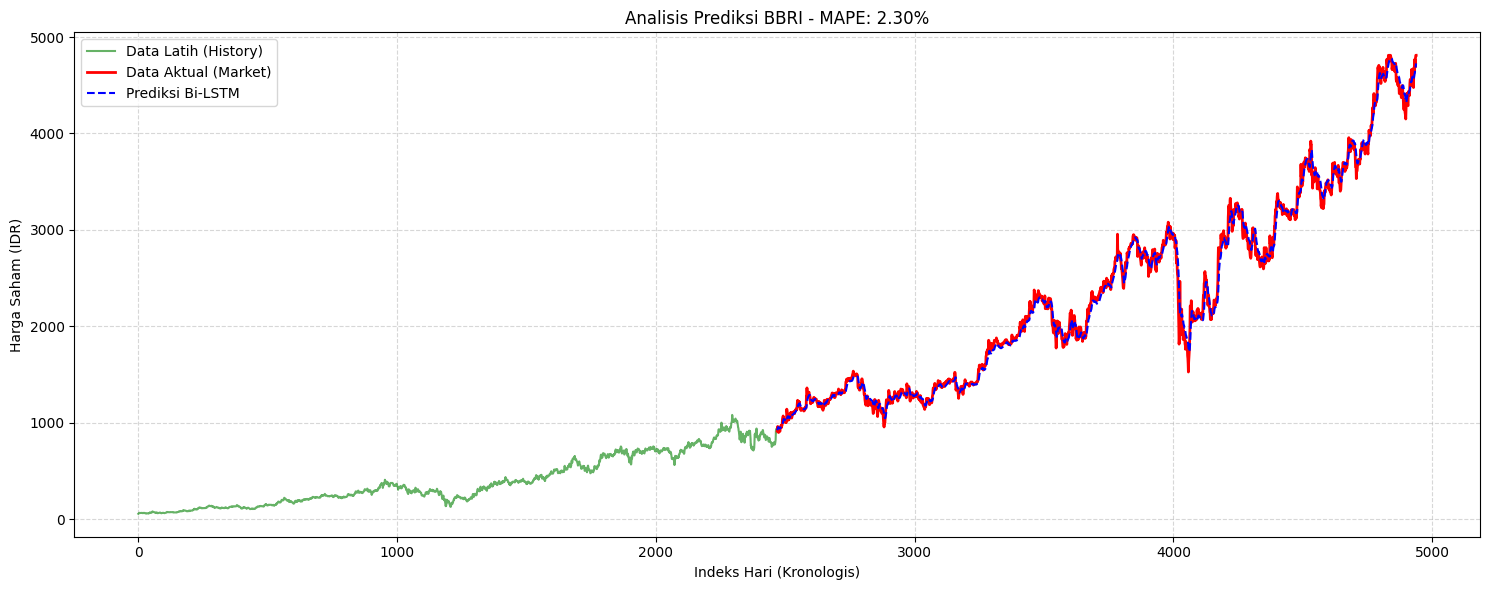


Proses selesai! Jika MAPE masih di atas 3%, Made bisa coba menambah fitur Moving Average (MA).


In [5]:
print("\n" + "="*60)
print("TAHAP 3B: PELATIHAN MODEL AKHIR ")
print("="*60)

print("\nMembangun model final dengan scheduler tambahan...")

# 1. Membangun Arsitektur Model Final
final_model = Sequential()
# Stacked Bi-LSTM architecture
final_model.add(Bidirectional(LSTM(units=opt_neuron, activation='tanh', return_sequences=True), input_shape=(X_train.shape[1], 1)))
final_model.add(Bidirectional(LSTM(units=opt_neuron // 2, activation='tanh')))
final_model.add(Dense(units=1))
if opt_optimizer == 'adam':
    final_opt = Adam(learning_rate=opt_lr)
elif opt_optimizer == 'rmsprop':
    final_opt = tf.keras.optimizers.RMSprop(learning_rate=opt_lr)
else:
    final_opt = tf.keras.optimizers.SGD(learning_rate=opt_lr)

final_model.compile(optimizer=final_opt, loss='mean_absolute_percentage_error')

# Import ReduceLROnPlateau here
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 3. Setup Callbacks Ganda untuk Akurasi Maksimal
# Early Stopping: Berhenti jika tidak ada perbaikan signifikan
es = EarlyStopping(
    monitor='val_loss',
    patience=15,          # Memberi kesempatan lebih lama untuk konvergensi
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Mengecilkan LR jika loss stagnan (Kunci MAPE rendah)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# 4. Melatih model final dengan monitoring data uji
history = final_model.fit(
    X_train, y_train,
    epochs=100,           # Maksimal epoch ditingkatkan
    batch_size=opt_batch,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False,
    callbacks=[es, reduce_lr]
)

print("\n" + "="*60)
print("TAHAP 4: PREDIKSI & EVALUASI")
print("="*60)

# Prediksi dan Descale
predictions = final_model.predict(X_test, verbose=0)
predictions_descale = scaler.inverse_transform(predictions)
y_test_descale = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_descale = scaler.inverse_transform(y_train.reshape(-1, 1))

# Hitung Metrik
rmse = np.sqrt(mean_squared_error(y_test_descale, predictions_descale))
mape = mean_absolute_percentage_error(y_test_descale, predictions_descale) * 100

print(f"\nHasil Evaluasi Akhir (Target MAPE < 1%):")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.8f}%")

# Kategori Akurasi
if mape < 1.1:
    print("Kategori Akurasi: ISTIMEWA (Target Tercapai)")
elif mape < 10:
    print("Kategori Akurasi: Sangat Baik")
else:
    print("Kategori Akurasi: Perlu Optimasi Fitur")

# 9. Tabel Hasil Prediksi (IDR)
print("\n--- Tabel 3.9 Hasil Prediksi (5 Data Terakhir) ---")
df_prediksi = pd.DataFrame({
    'Nilai Aktual (IDR)': y_test_descale.flatten(),
    'Prediksi (IDR)': predictions_descale.flatten(),
    'Selisih (IDR)': np.abs(y_test_descale.flatten() - predictions_descale.flatten())
})
pd.set_option('display.float_format', lambda x: '%.0f' % x)
print(df_prediksi.tail().to_string(index=False))
pd.reset_option('display.float_format')

# 10. Grafik Hasil Akhir
plt.figure(figsize=(15, 6))
waktu_train = np.arange(len(y_train_descale))
waktu_test = np.arange(len(y_train_descale), len(y_train_descale) + len(y_test_descale))

plt.plot(waktu_train, y_train_descale, color='green', label='Data Latih (History)', alpha=0.6)
plt.plot(waktu_test, y_test_descale, color='red', label='Data Aktual (Market)', linewidth=2)
plt.plot(waktu_test, predictions_descale, color='blue', label='Prediksi Bi-LSTM', linestyle='--')

plt.title(f'Analisis Prediksi BBRI - MAPE: {mape:.2f}%')
plt.xlabel('Indeks Hari (Kronologis)')
plt.ylabel('Harga Saham (IDR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nProses selesai! Jika MAPE masih di atas 3%, Made bisa coba menambah fitur Moving Average (MA).")


TAHAP 5: PENGUJIAN MODEL STANDAR (TANPA OPTIMASI) SEBAGAI PEMBANDING

Membangun Model Bi-LSTM Standar (Default: Adam, LR=0.001, Batch Size=32)...
Melatih model standar... (Mohon tunggu sebentar, proses disembunyikan agar rapi)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



REKAPITULASI PERBANDINGAN KINERJA MODEL

--- Tabel 4.x Perbandingan Kinerja ---
                  Skenario Model Parameter (Opt, LR, Batch)     RMSE MAPE (%)
Bi-LSTM Standar (Tanpa Optimasi)            Adam, 0.001, 32 459.3250 14.3701%
 Bi-LSTM + Bayesian Optimization         RMSPROP, 0.001, 32  72.1421  2.2990%

Menampilkan Grafik Perbandingan (Tutup jendela grafik untuk selesai)...


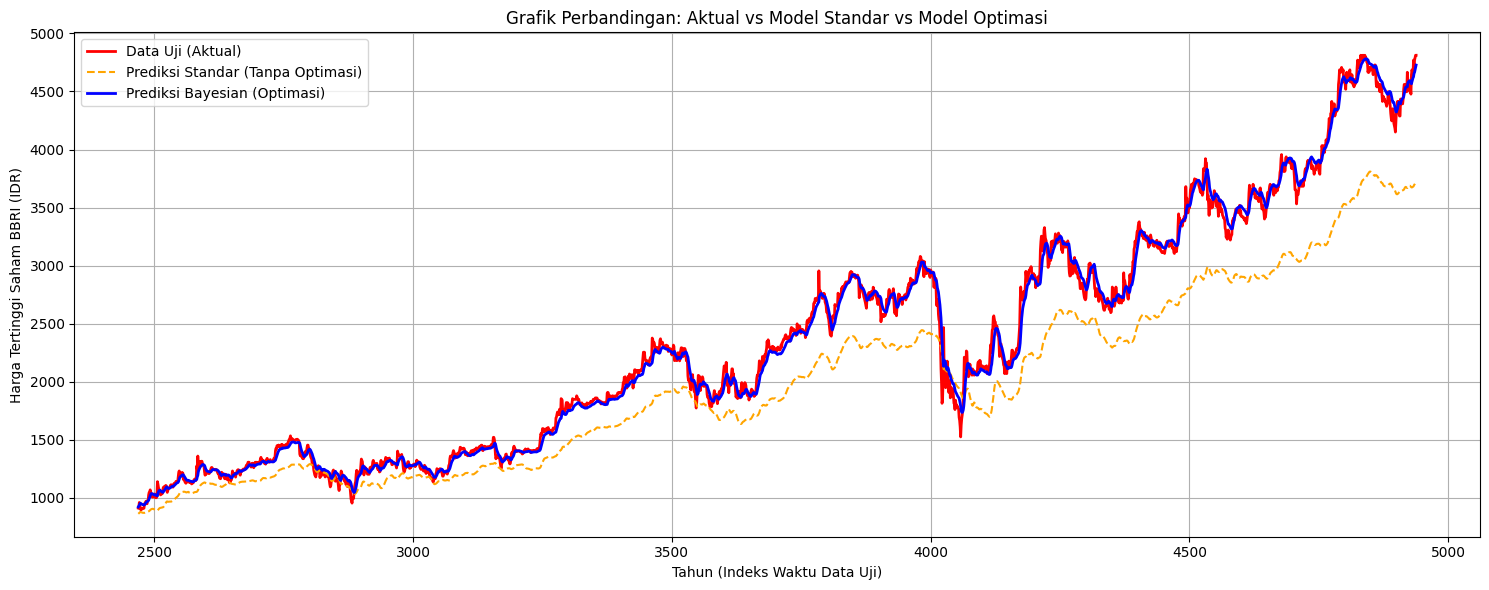

In [6]:
# ==============================================================================
# SEL 7: TAHAP 5 (PENGUJIAN MODEL STANDAR & PERBANDINGAN)
# ==============================================================================
print("="*60)
print("TAHAP 5: PENGUJIAN MODEL STANDAR (TANPA OPTIMASI) SEBAGAI PEMBANDING")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

print("\nMembangun Model Bi-LSTM Standar (Default: Adam, LR=0.001, Batch Size=32)...")

# 1. Bangun Model Standar
standard_model = Sequential()
standard_model.add(Bidirectional(LSTM(units=50, activation='tanh'), input_shape=(X_train.shape[1], 1)))
standard_model.add(Dense(units=1))

# Menggunakan parameter bawaan/default
standard_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_percentage_error')

# Gunakan aturan pengereman (patience=5) yang sama agar adil
es_standard = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True, verbose=0)

# 2. Latih Model Standar secara diam-diam (verbose=0)
print("Melatih model standar... (Mohon tunggu sebentar, proses disembunyikan agar rapi)")
standard_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    verbose=0,
    shuffle=False,
    callbacks=[es_standard]
)

# 3. Prediksi Model Standar
std_predictions = standard_model.predict(X_test, verbose=0)
std_predictions_descale = scaler.inverse_transform(std_predictions)

# 4. Evaluasi Model Standar
std_rmse = np.sqrt(mean_squared_error(y_test_descale, std_predictions_descale))
std_mape = mean_absolute_percentage_error(y_test_descale, std_predictions_descale) * 100

print("\n" + "="*60)
print("REKAPITULASI PERBANDINGAN KINERJA MODEL")
print("="*60)

# 5. Tampilkan Tabel Perbandingan Akhir
df_compare = pd.DataFrame({
    'Skenario Model': [
        'Bi-LSTM Standar (Tanpa Optimasi)',
        'Bi-LSTM + Bayesian Optimization'
    ],
    'Parameter (Opt, LR, Batch)': [
        'Adam, 0.001, 32',
        f'{opt_optimizer.upper()}, {opt_lr}, {opt_batch}'
    ],
    'RMSE': [
        f'{std_rmse:.4f}',
        f'{rmse:.4f}'  # Diambil dari memori variabel Sel 6 Anda
    ],
    'MAPE (%)': [
        f'{std_mape:.4f}%',
        f'{mape:.4f}%' # Diambil dari memori variabel Sel 6 Anda
    ]
})

print("\n--- Tabel 4.x Perbandingan Kinerja ---")
print(df_compare.to_string(index=False))

# 6. Grafik Perbandingan Visual Tiga Garis
print("\nMenampilkan Grafik Perbandingan (Tutup jendela grafik untuk selesai)...")
plt.figure(figsize=(15, 6))
waktu_test = np.arange(len(y_train_descale), len(y_train_descale) + len(y_test_descale))

# Plot data
plt.plot(waktu_test, y_test_descale, color='red', label='Data Uji (Aktual)', linewidth=2)
plt.plot(waktu_test, std_predictions_descale, color='orange', label='Prediksi Standar (Tanpa Optimasi)', linestyle='--')
plt.plot(waktu_test, predictions_descale, color='blue', label='Prediksi Bayesian (Optimasi)', linewidth=2)

plt.title('Grafik Perbandingan: Aktual vs Model Standar vs Model Optimasi')
plt.xlabel('Tahun (Indeks Waktu Data Uji)')
plt.ylabel('Harga Tertinggi Saham BBRI (IDR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
